# Repeated A* vs D* Lite on a Changing Grid

This notebook replaces the older split D* and D* Lite concept notebooks with one side-by-side comparison.

Learning goals:
- compare full replanning with repeated A* against true incremental repair with D* Lite,
- measure search work for a single map update and during execution,
- understand when D* Lite's extra bookkeeping pays off.

Notes:
- The repeated-A* baseline is executed directly.
- The D* Lite sections implement the actual incremental algorithm on a 4-connected occupancy grid.
- The comparison focuses on computational behavior, not production-level optimization.

In [1]:
%matplotlib inline

import heapq
import math

import matplotlib.pyplot as plt
import numpy as np

## 1. Build one grid world used by both planners

We keep the world, start, goal, and map updates identical so the comparison is fair.

The notebook uses two scenarios:
- a single map update while the robot is still at the start,
- repeated updates while the robot moves toward the goal.

In [2]:
H, W = 40, 40

def make_base_grid():
    grid_map = np.zeros((H, W), dtype=np.uint8)

    grid_map[8:32, 12] = 1
    grid_map[8:32, 28] = 1
    grid_map[20, 12:29] = 1

    grid_map[12, 12] = 0
    grid_map[30, 28] = 0
    grid_map[20, 20] = 0

    return grid_map

start = (2, 2)
goal = (37, 37)
base_grid = make_base_grid()

scheduled_updates = {
    6: [(20, 20), (21, 20), (22, 20)],
    14: [(30, 28), (30, 27), (30, 26)],
    22: [(12, 12), (13, 12), (14, 12)]
}

base_grid.shape, start, goal

((40, 40), (2, 2), (37, 37))

## 2. Shared search and plotting utilities

The baseline A* is the "replan from scratch" reference.

D* Lite uses the same grid and motion model, but keeps internal search values and repairs only what changed.

In [3]:
DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def in_bounds(r, c, h, w):
    return 0 <= r < h and 0 <= c < w

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def neighbors(node, shape):
    h, w = shape
    for dr, dc in DIRS:
        nr, nc = node[0] + dr, node[1] + dc
        if in_bounds(nr, nc, h, w):
            yield (nr, nc)

def reconstruct(parent, node):
    path = [node]
    while node in parent:
        node = parent[node]
        path.append(node)
    path.reverse()
    return path

def path_cost(path):
    if path is None:
        return math.inf
    return float(len(path) - 1)

def astar(grid_map, s, g):
    open_heap = []
    parent = {}
    g_cost = {s: 0.0}
    closed = set()

    heapq.heappush(open_heap, (heuristic(s, g), 0.0, s))
    expansions = 0

    while open_heap:
        _, curr_g, current = heapq.heappop(open_heap)
        if current in closed:
            continue

        closed.add(current)
        expansions += 1

        if current == g:
            return reconstruct(parent, current), g_cost[current], expansions

        for nxt in neighbors(current, grid_map.shape):
            if grid_map[nxt] == 1:
                continue

            new_g = curr_g + 1.0
            if new_g < g_cost.get(nxt, math.inf):
                g_cost[nxt] = new_g
                parent[nxt] = current
                priority = new_g + heuristic(nxt, g)
                heapq.heappush(open_heap, (priority, new_g, nxt))

    return None, math.inf, expansions

def block_cells(grid_map, cells, protected=()):
    protected = set(protected)
    changed = []
    for cell in cells:
        if cell in protected:
            continue
        r, c = cell
        if grid_map[r, c] == 0:
            grid_map[r, c] = 1
            changed.append(cell)
    return changed

def draw_grid(ax, grid_map, path=None, trajectory=None, start_node=None, goal_node=None, robot=None, title=''):
    ax.imshow(grid_map, cmap='Greys', origin='upper')

    if path is not None and len(path) > 0:
        xs = [p[1] for p in path]
        ys = [p[0] for p in path]
        ax.plot(xs, ys, color='deepskyblue', linewidth=2.0, label='path')

    if trajectory is not None and len(trajectory) > 0:
        xs = [p[1] for p in trajectory]
        ys = [p[0] for p in trajectory]
        ax.plot(xs, ys, color='orange', linewidth=2.0, label='trajectory')

    if start_node is not None:
        ax.scatter(start_node[1], start_node[0], c='limegreen', s=90, marker='o', label='start')
    if goal_node is not None:
        ax.scatter(goal_node[1], goal_node[0], c='crimson', s=90, marker='*', label='goal')
    if robot is not None:
        ax.scatter(robot[1], robot[0], c='gold', s=80, marker='s', label='robot')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), loc='upper right')

## 3. D* Lite implementation

This section implements true D* Lite on the same 4-connected grid.

Important difference from repeated A*:
- repeated A* throws away its search tree after every update,
- D* Lite keeps `g` and `rhs` values plus a priority queue, then repairs only the affected region.

In [4]:
class DStarLite:
    def __init__(self, grid_map, start_node, goal_node):
        self.grid = grid_map.copy()
        self.start = start_node
        self.goal = goal_node
        self.last = start_node
        self.km = 0.0

        self.g = {}
        self.rhs = {self.goal: 0.0}
        self.open_heap = []
        self.open_entries = {}

        self.queue_pops = 0
        self.vertex_updates = 0

        self._push(self.goal)

    def _g(self, node):
        return self.g.get(node, math.inf)

    def _rhs(self, node):
        return self.rhs.get(node, math.inf)

    def _is_free(self, node):
        return self.grid[node] == 0

    def _free_neighbors(self, node):
        if not self._is_free(node):
            return []
        return [nxt for nxt in neighbors(node, self.grid.shape) if self.grid[nxt] == 0]

    def calculate_key(self, node):
        best = min(self._g(node), self._rhs(node))
        return (best + heuristic(self.start, node) + self.km, best)

    def _push(self, node):
        key = self.calculate_key(node)
        self.open_entries[node] = key
        heapq.heappush(self.open_heap, (key[0], key[1], node))

    def _remove(self, node):
        self.open_entries.pop(node, None)

    def _top_key(self):
        while self.open_heap:
            k1, k2, node = self.open_heap[0]
            current_key = self.open_entries.get(node)
            if current_key is None or current_key != (k1, k2):
                heapq.heappop(self.open_heap)
                continue
            return (k1, k2)
        return (math.inf, math.inf)

    def _pop(self):
        while self.open_heap:
            k1, k2, node = heapq.heappop(self.open_heap)
            current_key = self.open_entries.get(node)
            if current_key is None or current_key != (k1, k2):
                continue
            del self.open_entries[node]
            self.queue_pops += 1
            return (k1, k2), node
        return (math.inf, math.inf), None

    def update_vertex(self, node):
        self.vertex_updates += 1

        if node != self.goal:
            nbrs = self._free_neighbors(node)
            if nbrs:
                self.rhs[node] = min(1.0 + self._g(nxt) for nxt in nbrs)
            else:
                self.rhs[node] = math.inf

        if self._g(node) != self._rhs(node):
            self._push(node)
        else:
            self._remove(node)

    def compute_shortest_path(self, max_iterations=200000):
        local_pops = 0
        while (self._top_key() < self.calculate_key(self.start)) or (self._rhs(self.start) != self._g(self.start)):
            if local_pops >= max_iterations:
                raise RuntimeError('D* Lite exceeded the iteration budget.')

            old_key, node = self._pop()
            if node is None:
                break

            local_pops += 1
            new_key = self.calculate_key(node)

            if old_key < new_key:
                self.open_entries[node] = new_key
                heapq.heappush(self.open_heap, (new_key[0], new_key[1], node))
            elif self._g(node) > self._rhs(node):
                self.g[node] = self._rhs(node)
                for pred in self._free_neighbors(node):
                    self.update_vertex(pred)
            else:
                self.g[node] = math.inf
                self.update_vertex(node)
                for pred in self._free_neighbors(node):
                    self.update_vertex(pred)

        return local_pops

    def get_path(self, max_length=10000):
        if math.isinf(self._rhs(self.start)) and math.isinf(self._g(self.start)):
            return None

        path = [self.start]
        current = self.start
        visited = {current}

        while current != self.goal:
            options = []
            for nxt in self._free_neighbors(current):
                value = 1.0 + self._g(nxt)
                options.append((value, heuristic(nxt, self.goal), nxt))

            if not options:
                return None

            value, _, best = min(options)
            if math.isinf(value) or best in visited:
                return None

            current = best
            path.append(current)
            visited.add(current)

            if len(path) > max_length:
                return None

        return path

    def apply_obstacle_updates(self, changed_cells):
        affected = set()
        for cell in changed_cells:
            affected.add(cell)
            for nbr in neighbors(cell, self.grid.shape):
                affected.add(nbr)

        for cell in changed_cells:
            self.grid[cell] = 1
            self.g[cell] = math.inf
            self.rhs[cell] = math.inf
            self._remove(cell)

        for cell in affected:
            if self.grid[cell] == 0:
                self.update_vertex(cell)

        return self.compute_shortest_path()

    def move_start(self, new_start):
        self.km += heuristic(self.last, new_start)
        self.last = new_start
        self.start = new_start

## 4. Single-update comparison from the same start state

First we reproduce the classic "path becomes invalid after a map update" case.

Then we compare:
- repeated A*: run a brand new search after the update,
- D* Lite: repair the previous search state after the update.

Single update comparison
------------------------------------------------------------
Changed cells: [(20, 20), (21, 20), (22, 20), (23, 20)]
Repeated A* initial expansions: 1159
Repeated A* replan expansions after update: 1069
D* Lite queue pops for initial plan: 1152
D* Lite queue pops for repair: 97
A* updated path cost: 70.0
D* Lite repaired path cost: 70.0


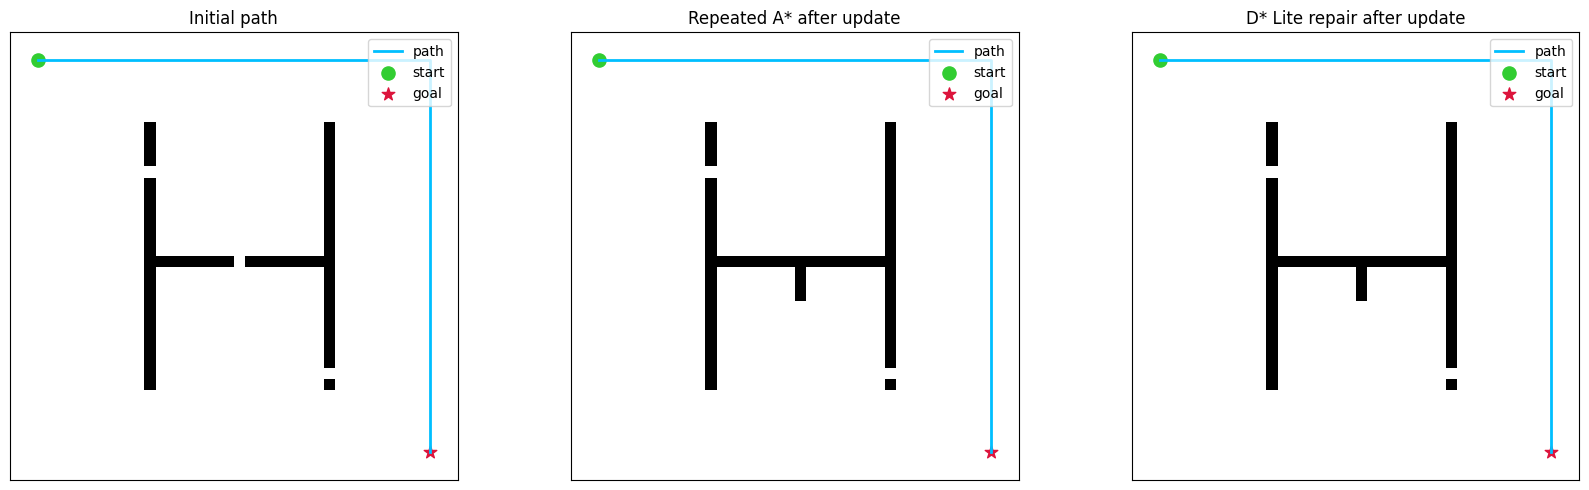

In [5]:
single_grid = make_base_grid()

astar_path_before, astar_cost_before, astar_exp_before = astar(single_grid, start, goal)

planner = DStarLite(make_base_grid(), start, goal)
dstar_initial_pops = planner.compute_shortest_path()
dstar_path_before = planner.get_path()
dstar_cost_before = path_cost(dstar_path_before)

single_update_cells = [(20, 20), (21, 20), (22, 20), (23, 20)]
changed_cells = block_cells(single_grid, single_update_cells, protected={start, goal})

astar_path_after, astar_cost_after, astar_exp_after = astar(single_grid, start, goal)

dstar_repair_pops = planner.apply_obstacle_updates(changed_cells)
dstar_path_after = planner.get_path()
dstar_cost_after = path_cost(dstar_path_after)

print('Single update comparison')
print('-' * 60)
print(f'Changed cells: {changed_cells}')
print(f'Repeated A* initial expansions: {astar_exp_before}')
print(f'Repeated A* replan expansions after update: {astar_exp_after}')
print(f'D* Lite queue pops for initial plan: {dstar_initial_pops}')
print(f'D* Lite queue pops for repair: {dstar_repair_pops}')
print(f'A* updated path cost: {astar_cost_after:.1f}')
print(f'D* Lite repaired path cost: {dstar_cost_after:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
draw_grid(axes[0], make_base_grid(), path=astar_path_before, start_node=start, goal_node=goal, title='Initial path')
draw_grid(axes[1], single_grid, path=astar_path_after, start_node=start, goal_node=goal, title='Repeated A* after update')
draw_grid(axes[2], single_grid, path=dstar_path_after, start_node=start, goal_node=goal, title='D* Lite repair after update')
plt.tight_layout()
plt.show()

Dynamic execution comparison
------------------------------------------------------------
Repeated A* total expansions: 19905
D* Lite initial queue pops: 1152
D* Lite total queue pops including repairs: 1267
D* Lite vertex updates: 5054
Repeated A* goal reached: True
D* Lite goal reached: True


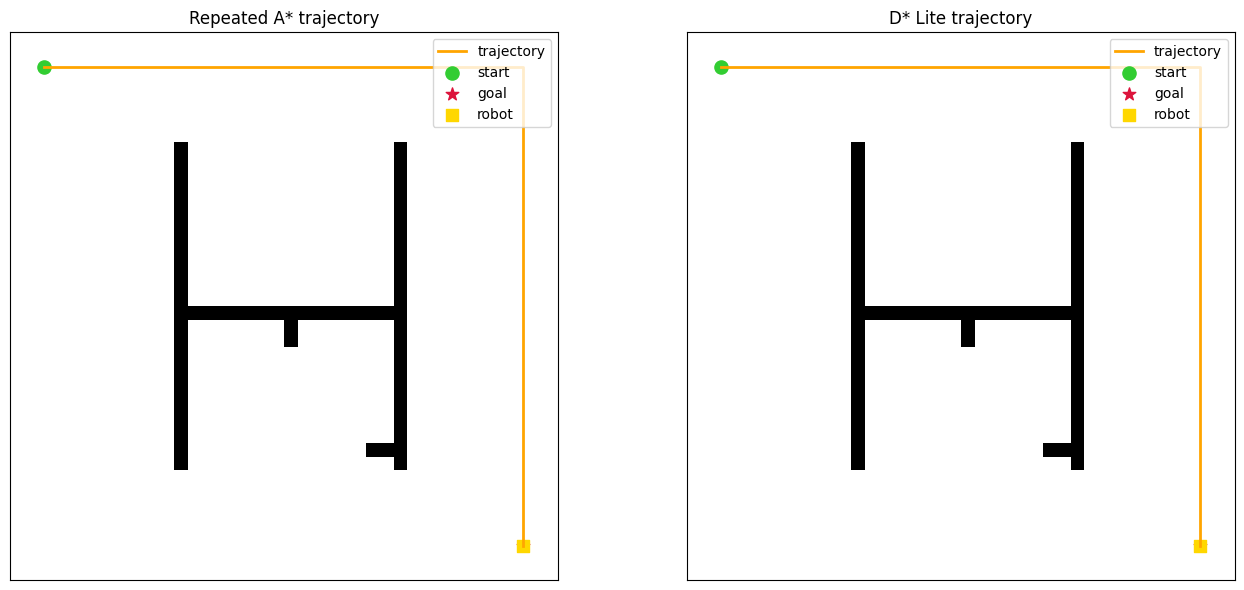

In [7]:
def run_repeated_astar_trial(grid_map, start_node, goal_node, updates, max_steps=70):
    world = grid_map.copy()
    robot = start_node
    trajectory = [robot]
    total_expansions = 0
    logs = []

    for t in range(max_steps):
        if robot == goal_node:
            break

        changed = block_cells(world, updates.get(t, []), protected={robot, goal_node})
        path, cost, expansions = astar(world, robot, goal_node)
        total_expansions += expansions
        logs.append((t, robot, len(changed), expansions, cost))

        if path is None or len(path) < 2:
            break

        robot = path[1]
        trajectory.append(robot)

    return {
        'world': world,
        'robot': robot,
        'trajectory': trajectory,
        'total_expansions': total_expansions,
        'logs': logs,
    }

def run_dstar_lite_trial(grid_map, start_node, goal_node, updates, max_steps=70):
    planner = DStarLite(grid_map, start_node, goal_node)
    initial_pops = planner.compute_shortest_path()
    trajectory = [start_node]
    repair_log = []
    total_repair_pops = initial_pops

    for t in range(max_steps):
        if planner.start == goal_node:
            break

        changed = block_cells(planner.grid, updates.get(t, []), protected={planner.start, goal_node})
        repair_pops = 0
        if changed:
            repair_pops = planner.apply_obstacle_updates(changed)
            total_repair_pops += repair_pops

        path = planner.get_path()
        repair_log.append((t, planner.start, len(changed), repair_pops, path_cost(path)))

        if path is None or len(path) < 2:
            break

        next_state = path[1]
        planner.move_start(next_state)
        trajectory.append(next_state)

    return {
        'world': planner.grid.copy(),
        'robot': planner.start,
        'trajectory': trajectory,
        'initial_queue_pops': initial_pops,
        'total_repair_pops': total_repair_pops,
        'vertex_updates': planner.vertex_updates,
        'logs': repair_log,
    }

astar_trial = run_repeated_astar_trial(make_base_grid(), start, goal, scheduled_updates)
dstar_trial = run_dstar_lite_trial(make_base_grid(), start, goal, scheduled_updates)

print('Dynamic execution comparison')
print('-' * 60)
print(f"Repeated A* total expansions: {astar_trial['total_expansions']}")
print(f"D* Lite initial queue pops: {dstar_trial['initial_queue_pops']}")
print(f"D* Lite total queue pops including repairs: {dstar_trial['total_repair_pops']}")
print(f"D* Lite vertex updates: {dstar_trial['vertex_updates']}")
print(f"Repeated A* goal reached: {astar_trial['robot'] == goal}")
print(f"D* Lite goal reached: {dstar_trial['robot'] == goal}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_grid(
    axes[0],
    astar_trial['world'],
    trajectory=astar_trial['trajectory'],
    start_node=start,
    goal_node=goal,
    robot=astar_trial['robot'],
    title='Repeated A* trajectory',
)
draw_grid(
    axes[1],
    dstar_trial['world'],
    trajectory=dstar_trial['trajectory'],
    start_node=start,
    goal_node=goal,
    robot=dstar_trial['robot'],
    title='D* Lite trajectory',
)
plt.tight_layout()
plt.show()

## 5. Read the comparison carefully

What to look for:
- Repeated A* usually spends work on every replan, even when only a small part of the map changed.
- D* Lite pays an upfront bookkeeping cost, then often repairs more cheaply when updates are local.
- Both methods can return the same path cost on the same grid; the main difference is how much computation gets reused.

A compact side-by-side summary:

| Aspect | Repeated A* | D* Lite |
| --- | --- | --- |
| Search state after an update | discarded | repaired |
| Typical trigger | any replan request | edge-cost / obstacle change |
| Main work metric in this notebook | node expansions | queue pops and vertex updates |
| Best use case | simple or infrequent replanning | repeated local map updates |
| Implementation complexity | low | higher |

Try it yourself:
1. Add another obstacle update and rerun the notebook.
2. Move one update earlier so it disrupts the path more strongly.
3. Compare how much the repeated-A* total grows versus the D* Lite repair cost.